# Integral Lines of a Vector Field

## Definition

Given a smooth vector field $v : \Omega \subset \mathbb{R}^2 \to \mathbb{R}^2$, an **integral line** (or **flow line** / **streamline**) starting at $x_0$ is the curve $\gamma : \mathbb{R} \to \Omega$ satisfying the ODE:
$$\dot{\gamma}(t) = v(\gamma(t)), \quad \gamma(0) = x_0$$

By the Picard–Lindelöf theorem, a unique solution exists locally when $v$ is Lipschitz.

## The Flow Map

The collection of all integral lines defines the **flow map** $\Phi_t : \Omega \to \Omega$, where $\Phi_t(x_0) = \gamma_{x_0}(t)$. Key properties:
- $\Phi_0 = \mathrm{id}$ (identity)
- $\Phi_{t+s} = \Phi_t \circ \Phi_s$ (group property / semigroup)
- If $v$ is divergence-free ($\nabla \cdot v = 0$), then $\Phi_t$ preserves area

## Visualization Methods

Several methods exist to visualize a 2D vector field via its integral lines:
- **Streamlines**: segments of integral lines from seeded starting points
- **Line Integral Convolution (LIC)**: convolves white noise along streamlines for a dense texture
- **Arrow plots** (quiver): show direction and magnitude at grid points

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from ipywidgets import interact, IntSlider, FloatSlider

### Generating a smooth random vector field

We create a smooth, periodic 2D vector field by Gaussian-blurring two independent white-noise arrays. This produces a divergence-containing field with rich structure. A blur scale $\sigma$ controls the coherence length of the flow.

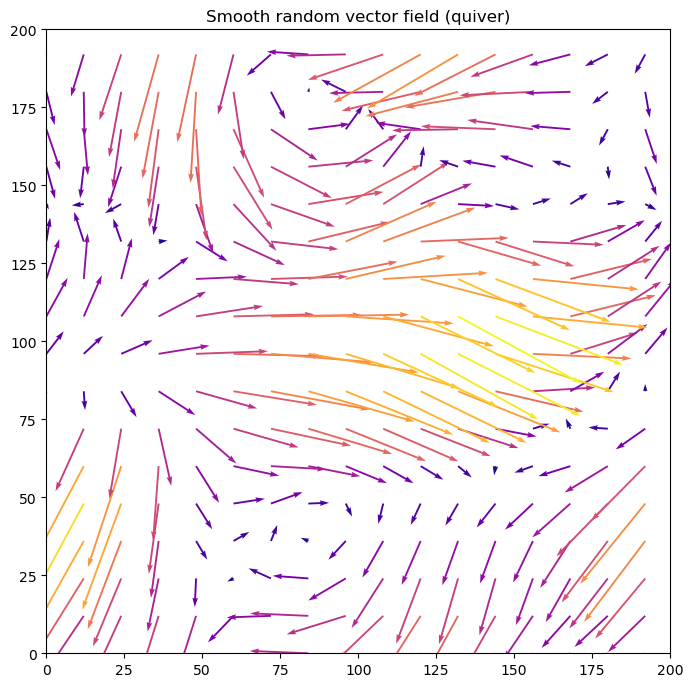

In [2]:
from scipy.ndimage import gaussian_filter

n = 200
rng = np.random.default_rng(42)

def make_vector_field(n, sigma=20, seed=42):
    rng = np.random.default_rng(seed)
    vx = gaussian_filter(rng.standard_normal((n, n)), sigma=sigma, mode='wrap')
    vy = gaussian_filter(rng.standard_normal((n, n)), sigma=sigma, mode='wrap')
    # Normalize to unit standard deviation
    speed = np.sqrt(vx**2 + vy**2).std()
    return vx / speed, vy / speed

vx, vy = make_vector_field(n, sigma=20)
speed = np.sqrt(vx**2 + vy**2)

# Quiver plot (subsampled)
fig, ax = plt.subplots(figsize=(7, 7))
s = 12
Y, X = np.mgrid[0:n:s, 0:n:s]
ax.quiver(X, Y, vx[::s,::s], vy[::s,::s], speed[::s,::s],
          cmap='plasma', scale=20, width=0.003)
ax.set_title('Smooth random vector field (quiver)')
ax.set_aspect('equal'); ax.set_xlim(0,n); ax.set_ylim(0,n)
plt.tight_layout(); plt.savefig('vfield.png', dpi=100, bbox_inches='tight'); plt.show()

### Integrating streamlines with Euler method

We integrate the ODE $\dot{\gamma} = v(\gamma)$ using the explicit Euler scheme:
$$\gamma(t + \Delta t) = \gamma(t) + \Delta t \cdot v(\gamma(t))$$

Bilinear interpolation evaluates $v$ at off-grid positions. Seeds are placed on a regular grid. To show both forward and backward integration, we double the seed set and negate the field for backward paths.

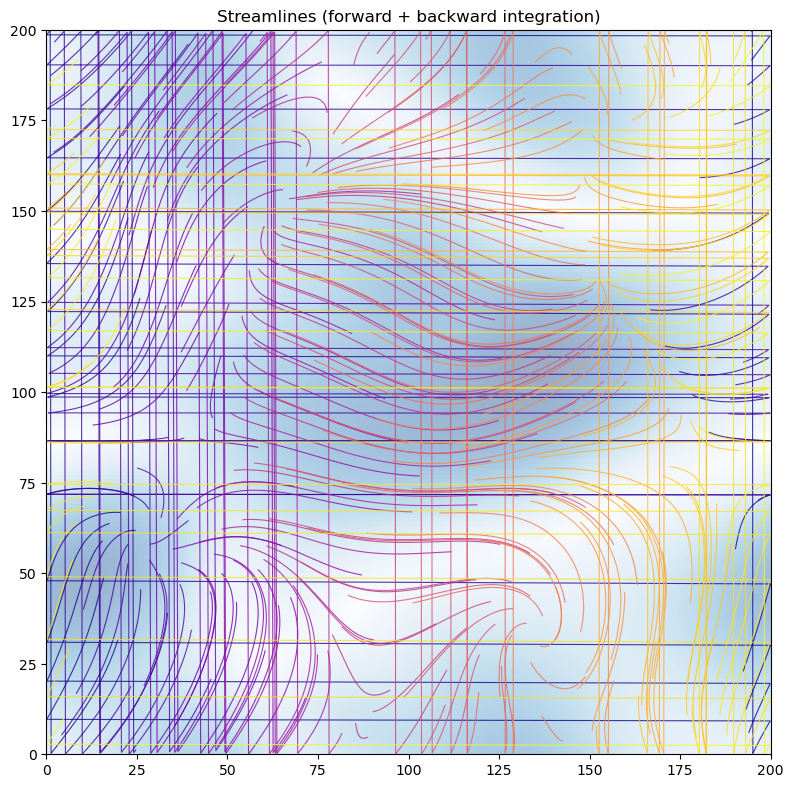

In [3]:
def interp_vfield(vx, vy, pos):
    """Bilinear interpolation of (vx, vy) at positions pos (M,2) in [0,n-1]^2."""
    coords = pos.T  # shape (2, M)
    u = map_coordinates(vx, coords, order=1, mode='wrap')
    v = map_coordinates(vy, coords, order=1, mode='wrap')
    return np.column_stack([u, v])

def integrate_streamlines(vx, vy, seeds, dt=0.5, n_steps=80):
    """Return list of (n_steps+1, 2) trajectories."""
    n = vx.shape[0]
    traj = [seeds.copy()]
    pos = seeds.copy()
    for _ in range(n_steps):
        vel = interp_vfield(vx, vy, pos)
        pos = pos + dt * vel
        pos = pos % n  # wrap
        traj.append(pos.copy())
    return np.array(traj)  # (n_steps+1, M, 2)

# Regular grid of seeds
p = 15
t = np.linspace(5, n-5, p)
Yg, Xg = np.meshgrid(t, t)
seeds = np.column_stack([Xg.ravel(), Yg.ravel()])

# Forward and backward
traj_fwd = integrate_streamlines(vx, vy, seeds, dt=0.35, n_steps=45)
traj_bwd = integrate_streamlines(-vx, -vy, seeds, dt=0.35, n_steps=45)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(speed, cmap='Blues', origin='lower', alpha=0.4, extent=[0,n,0,n])
# Draw streamlines
colors = plt.cm.plasma(np.linspace(0, 1, seeds.shape[0]))
for i in range(seeds.shape[0]):
    path_fwd = traj_fwd[:, i, :]  # (steps, 2)
    path_bwd = traj_bwd[:, i, :]
    full = np.vstack([path_bwd[::-1], path_fwd])
    ax.plot(full[:, 0], full[:, 1], color=colors[i], lw=0.8, alpha=0.8)
ax.set_title('Streamlines (forward + backward integration)')
ax.set_aspect('equal'); ax.set_xlim(0,n); ax.set_ylim(0,n)
plt.tight_layout(); plt.savefig('streamlines.png', dpi=100, bbox_inches='tight'); plt.show()

### Line Integral Convolution (LIC)

LIC is a dense visualization technique. A white noise texture $I$ is convolved along each streamline:
$$\text{LIC}(x) = \frac{1}{L} \int_{-L/2}^{L/2} I(\Phi_s(x))\, ds$$

This produces a textured image where the correlation structure perfectly traces the vector field directions, even in regions with very low speed.

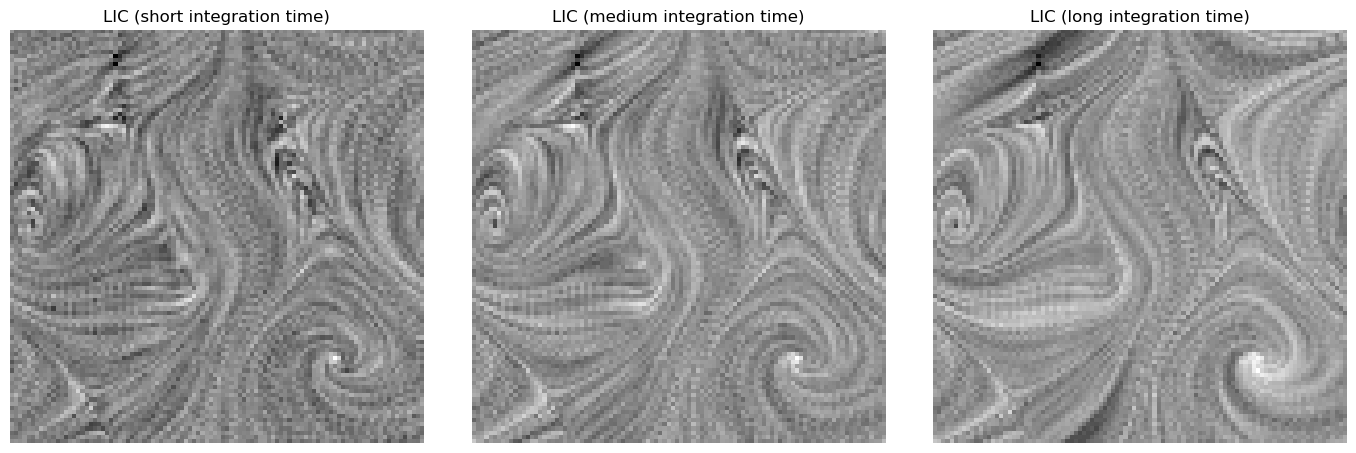

In [4]:
def lic(vx, vy, n_steps=15, dt=1.0, seed=0):
    rng_l = np.random.default_rng(seed)
    noise = rng_l.uniform(0, 1, vx.shape)
    n = vx.shape[0]
    Y, X = np.mgrid[0:n, 0:n]
    pos = np.column_stack([X.ravel().astype(float), Y.ravel().astype(float)])
    accum = np.zeros(n * n)
    for sign in [1, -1]:
        p = pos.copy()
        for _ in range(n_steps):
            vel = interp_vfield(vx * sign, vy * sign, p)
            p = (p + dt * vel) % n
            accum += map_coordinates(noise, p.T, order=1, mode='wrap')
    return (accum / (2 * n_steps)).reshape(n, n)

n_lic = 100
vx_s, vy_s = make_vector_field(n_lic, sigma=12, seed=99)
lic_short = lic(vx_s, vy_s, n_steps=6, dt=0.8)
lic_med = lic(vx_s, vy_s, n_steps=12, dt=0.8)
lic_long = lic(vx_s, vy_s, n_steps=24, dt=0.8)
lic_img = lic_med

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, img, ttl in zip(axes, [lic_short, lic_med, lic_long], ['short', 'medium', 'long']):
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(f'LIC ({ttl} integration time)')
    ax.axis('off')
plt.tight_layout(); plt.savefig('lic.png', dpi=100, bbox_inches='tight'); plt.show()


### Interactive: streamlines with varying step count

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(speed, cmap='Blues', origin='lower', alpha=0.4)
    cols = _plt.cm.plasma(np.linspace(0,1,seeds.shape[0]))
    for i in range(seeds.shape[0]):
        full = np.vstack([traj_bwd[::-1,i,:], traj_fwd[:,i,:]])
        axes[0].plot(full[:,0], full[:,1], color=cols[i], lw=0.8, alpha=0.8)
    axes[0].set_title('Streamlines'); axes[0].set_aspect('equal')
    axes[0].set_xlim(0,n); axes[0].set_ylim(0,n)
    axes[1].imshow(lic_img, cmap='gray', origin='lower')
    axes[1].set_title('LIC visualization'); axes[1].axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- Integral lines of a vector field $v$ solve the ODE $\dot{\gamma} = v(\gamma)$ and constitute the fundamental object for flow visualization.
- The **flow map** $\Phi_t$ satisfies the semigroup property and preserves area for divergence-free fields.
- **Streamlines** show selective paths; **LIC** produces a dense texture revealing all directional structure.
- Integration horizon and boundary handling strongly affect streamline quality.

## Bibliography

- B. Cabral & L. Leedom, *Imaging vector fields using line integral convolution*, SIGGRAPH 1993.
- R. McLachlan & G. Quispel, *Geometric integrators for ODEs*, J. Phys. A 39, 2006.